<a href="https://colab.research.google.com/github/Amruth-U-tech/Multi-Model-AI/blob/main/Colab-runs/image_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# =============================================================================
# CELL 1 — Title & Project Info
# =============================================================================
# %% [markdown]
"""
# 🖼️ Multi-Modal AI — Image Analysis Pipeline
## Dataset Quality, Preprocessing Validation & Visual Signal Estimation

**Pipeline Overview:**
- Load preprocessed CSV datasets (with image_path column)
- Validate required columns and image directory
- Dynamically construct full image paths
- Safely load and extract per-image statistics
- Generate visual distributions and random sample grids
- Print final insight summary for CNN readiness

**Goal:** Understand dataset quality and visual signal strength BEFORE training.
"""

# =============================================================================
# CELL 2 — Install & Import Dependencies
# =============================================================================
# %%
# ── Uncomment if running on fresh Colab ──────────────────────────────────────
# !pip install pandas numpy matplotlib pillow tqdm --quiet


In [1]:
!pip install pandas numpy matplotlib pillow tqdm --quiet


In [2]:
import os
import warnings
import random
import traceback
from typing import Optional, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   matplotlib : {plt.matplotlib.__version__}")


✅ All libraries imported successfully.
   pandas     : 2.2.2
   numpy      : 2.0.2
   matplotlib : 3.10.0


# =============================================================================
# CELL 3 — Configuration (Single Source of Truth — Edit Only Here)
# =============================================================================
# %%

# ── List of preprocessed CSV dataset paths

In [3]:
CSV_FILES = [
    "/content/drive/MyDrive/preprocessed-datasets/sample_100.csv"
]

# ── Shared image base directory (images are stored as {asin}.jpg here) ────────
IMAGE_BASE_DIR = "/content/drive/MyDrive/preprocessed-datasets/images"

# ── Max images to show in the random visual sample grid ──────────────────────
MAX_SAMPLE_DISPLAY = 16

# ── Reproducibility seed ─────────────────────────────────────────────────────
RANDOM_SEED = 42

print("✅ Configuration loaded.")
print(f"   CSV files       : {len(CSV_FILES)}")
print(f"   Image base dir  : {IMAGE_BASE_DIR}")
print(f"   Max grid display: {MAX_SAMPLE_DISPLAY}")


✅ Configuration loaded.
   CSV files       : 1
   Image base dir  : /content/drive/MyDrive/preprocessed-datasets/images
   Max grid display: 16


# =============================================================================
# CELL 4 — Validation Helpers
# =============================================================================
# %%

In [4]:
def validate_dataset_inputs(csv_path: str, image_base_dir: str) -> bool:
    """
    Validates all required inputs before processing a dataset.

    Checks:
      1. CSV file exists on disk
      2. image_path column is present in CSV
      3. IMAGE_BASE_DIR directory exists

    Args:
        csv_path       : Absolute path to the CSV dataset file.
        image_base_dir : Absolute path to the shared image directory.

    Returns:
        True if all checks pass, False otherwise (caller should skip).
    """
    dataset_name = os.path.basename(csv_path)

    # ── Check 1: CSV file exists ──────────────────────────────────────────────
    if not os.path.exists(csv_path):
        print(f"   ❌ [SKIP] CSV file not found: {csv_path}")
        return False

    # ── Check 2: image_path column present ───────────────────────────────────
    try:
        df_peek = pd.read_csv(csv_path, nrows=1)
    except Exception as e:
        print(f"   ❌ [SKIP] Cannot read CSV '{dataset_name}': {e}")
        return False

    if "image_path" not in df_peek.columns:
        print(f"   ❌ [SKIP] 'image_path' column missing in '{dataset_name}'.")
        print(f"      Available columns: {list(df_peek.columns)}")
        return False

    # ── Check 3: IMAGE_BASE_DIR exists ───────────────────────────────────────
    if not os.path.isdir(image_base_dir):
        print(f"   ❌ [SKIP] IMAGE_BASE_DIR does not exist: {image_base_dir}")
        return False

    return True


print("✅ validate_dataset_inputs() defined.")


✅ validate_dataset_inputs() defined.


# =============================================================================
# CELL 5 — Core Image Analysis Function
# =============================================================================
# %%


In [5]:
def analyze_image(full_image_path: str) -> Optional[Dict]:
    """
    Safely loads a single image and extracts statistical features.

    Extracted metrics:
      - width, height           : Pixel dimensions
      - aspect_ratio            : width / height
      - file_size_kb            : File size in kilobytes
      - image_mode              : PIL mode (e.g. RGB, RGBA, L)
      - avg_intensity           : Mean pixel value across all channels (0–255)
      - std_intensity           : Std dev of pixel values (richness proxy)

    Edge cases handled:
      - Missing path / NaN
      - File does not exist on disk
      - Zero-byte file
      - PIL cannot open / corrupted image
      - Any unexpected exception

    Args:
        full_image_path : Absolute path to the image file.

    Returns:
        Dict of stats on success, None on any failure.
    """
    # ── Guard: missing or NaN path ────────────────────────────────────────────
    if not full_image_path or pd.isna(full_image_path):
        return None

    full_image_path = str(full_image_path).strip()

    # ── Guard: file does not exist ────────────────────────────────────────────
    if not os.path.isfile(full_image_path):
        return None

    # ── Guard: zero-byte file ─────────────────────────────────────────────────
    try:
        file_size_bytes = os.path.getsize(full_image_path)
    except OSError:
        return None

    if file_size_bytes == 0:
        return None

    file_size_kb = round(file_size_bytes / 1024, 2)

    # ── Load image safely ─────────────────────────────────────────────────────
    try:
        img = Image.open(full_image_path)
        img.verify()                        # Catches truncated / corrupted files
        img = Image.open(full_image_path)   # Re-open after verify (PIL requirement)
    except Exception:
        return None

    # ── Extract dimensions ────────────────────────────────────────────────────
    try:
        width, height     = img.size
        aspect_ratio      = round(width / height, 4) if height > 0 else None
        image_mode        = img.mode

        # ── Pixel intensity stats (convert to numpy for speed) ────────────────
        img_rgb           = img.convert("RGB")
        pixel_array       = np.array(img_rgb, dtype=np.float32)
        avg_intensity     = round(float(np.mean(pixel_array)), 4)
        std_intensity     = round(float(np.std(pixel_array)), 4)

    except Exception:
        return None

    return {
        "width"        : int(width),
        "height"       : int(height),
        "aspect_ratio" : aspect_ratio,
        "file_size_kb" : file_size_kb,
        "image_mode"   : image_mode,
        "avg_intensity": avg_intensity,
        "std_intensity": std_intensity,
    }


print("✅ analyze_image() defined.")

✅ analyze_image() defined.


# =============================================================================
# CELL 6 — Dataset-Level Statistics Extractor
# =============================================================================
# %%

In [6]:
def extract_dataset_stats(
    df: pd.DataFrame,
    image_base_dir: str,
    dataset_name: str,
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Iterates through the dataset, constructs full image paths, and runs
    analyze_image() on each row. Collects results into a stats DataFrame.

    Args:
        df             : Loaded dataset DataFrame with 'image_path' column.
        image_base_dir : Shared image directory base path.
        dataset_name   : Human-readable label for tqdm progress bar.

    Returns:
        stats_df    : DataFrame of per-image statistics (successful rows only).
        failed_list : List of image filenames that failed to load/analyze.
    """
    stats_rows  = []
    failed_list = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Analyzing {dataset_name}"):

        raw_image_path = row.get("image_path", None)

        # ── Guard: missing image_path value in row ────────────────────────────
        if pd.isna(raw_image_path) or not str(raw_image_path).strip():
            failed_list.append(str(raw_image_path))
            continue

        # ── Dynamically construct full path ───────────────────────────────────
        # CSV stores only:  B001J63LJQ.jpg
        # We join with base: D:/multi-model-ai/images/B001J63LJQ.jpg
        full_path = os.path.join(image_base_dir, str(raw_image_path).strip())

        stats = analyze_image(full_path)

        if stats is None:
            failed_list.append(str(raw_image_path))
            continue

        # ── Attach source metadata ────────────────────────────────────────────
        stats["image_filename"] = os.path.basename(full_path)
        stats["full_path"]      = full_path
        stats_rows.append(stats)

    stats_df = pd.DataFrame(stats_rows) if stats_rows else pd.DataFrame()
    return stats_df, failed_list


print("✅ extract_dataset_stats() defined.")



✅ extract_dataset_stats() defined.


# =============================================================================
# CELL 7 — Visualization Functions
# =============================================================================
# %%


In [7]:
def plot_distributions(stats_df: pd.DataFrame, dataset_name: str) -> None:
    """
    Generates a 5-panel distribution plot for key image statistics:
      - Width distribution
      - Height distribution
      - Aspect ratio distribution
      - File size distribution
      - Average pixel intensity distribution

    Args:
        stats_df     : DataFrame of per-image statistics.
        dataset_name : Used as the figure title.
    """
    if stats_df.empty:
        print("   ⚠️  No stats available — skipping distribution plots.")
        return

    metrics = [
        ("width",         "Image Width (px)",           "#4C72B0"),
        ("height",        "Image Height (px)",          "#DD8452"),
        ("aspect_ratio",  "Aspect Ratio (W/H)",         "#55A868"),
        ("file_size_kb",  "File Size (KB)",             "#C44E52"),
        ("avg_intensity", "Avg Pixel Intensity (0–255)","#8172B2"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(24, 4))
    fig.suptitle(
        f"📊 Image Distribution Analysis — {dataset_name}",
        fontsize=14, fontweight="bold", y=1.02
    )

    for ax, (col, label, color) in zip(axes, metrics):
        if col not in stats_df.columns:
            ax.set_visible(False)
            continue

        data = stats_df[col].dropna()
        ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2,
                   label=f"Mean: {data.mean():.1f}")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"   ✅ Distribution plots rendered for '{dataset_name}'.")


def plot_image_samples(
    stats_df: pd.DataFrame,
    dataset_name: str,
    max_samples: int = 16,
    seed: int = 42,
) -> None:
    """
    Displays a random grid of loaded images for manual visual inspection.

    Args:
        stats_df     : DataFrame containing 'full_path' column.
        dataset_name : Used as the grid title.
        max_samples  : Maximum number of images to display.
        seed         : Random seed for reproducible sampling.
    """
    if stats_df.empty or "full_path" not in stats_df.columns:
        print("   ⚠️  No image paths available — skipping sample grid.")
        return

    valid_paths = stats_df["full_path"].dropna().tolist()

    if not valid_paths:
        print("   ⚠️  No valid image paths found — skipping sample grid.")
        return

    random.seed(seed)
    sample_paths = random.sample(valid_paths, min(max_samples, len(valid_paths)))
    n            = len(sample_paths)
    cols         = min(4, n)
    rows         = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    fig.suptitle(
        f"🖼️  Random Image Samples — {dataset_name}  (n={n})",
        fontsize=13, fontweight="bold"
    )

    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for idx, ax in enumerate(axes_flat):
        if idx < len(sample_paths):
            try:
                img = Image.open(sample_paths[idx]).convert("RGB")
                ax.imshow(img)
                ax.set_title(
                    os.path.basename(sample_paths[idx]),
                    fontsize=7, pad=2
                )
            except Exception:
                ax.text(0.5, 0.5, "Load Error", ha="center", va="center",
                        transform=ax.transAxes, color="red")
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"   ✅ Sample grid rendered ({n} images).")


print("✅ plot_distributions() and plot_image_samples() defined.")


✅ plot_distributions() and plot_image_samples() defined.


# =============================================================================
# CELL 8 — Insight Summary Printer
# =============================================================================
# %%

In [8]:
def print_insight_summary(
    stats_df: pd.DataFrame,
    failed_list: List[str],
    dataset_name: str,
) -> None:
    """
    Prints a structured analysis summary answering the 8 key diagnostic
    questions about dataset quality and CNN readiness.

    Questions answered:
      1. Are image dimensions mostly consistent?
      2. Did preprocessing/resizing work correctly?
      3. Are images visually rich or mostly plain?
      4. Is there strong variation in image sizes?
      5. Are most images high-quality or low-quality?
      6. Is the image modality likely useful for CNN learning?
      7. Are there corrupted or problematic images?
      8. Does the dataset appear visually biased?

    Args:
        stats_df     : DataFrame of per-image statistics.
        failed_list  : List of filenames that failed analysis.
        dataset_name : Dataset label for display.
    """
    total_attempted = len(stats_df) + len(failed_list)

    print("\n" + "=" * 65)
    print(f"  🔍  IMAGE ANALYSIS INSIGHT SUMMARY — {dataset_name}")
    print("=" * 65)

    print(f"\n  📌 Total images attempted : {total_attempted}")
    print(f"  📌 Successfully analyzed  : {len(stats_df)}")
    print(f"  📌 Failed / Corrupted     : {len(failed_list)}")
    if total_attempted > 0:
        success_rate = len(stats_df) / total_attempted * 100
        print(f"  📌 Success rate           : {success_rate:.1f}%")

    if stats_df.empty:
        print("\n  ⚠️  No valid image data to analyze.")
        print("=" * 65)
        return

    w   = stats_df["width"]
    h   = stats_df["height"]
    ar  = stats_df["aspect_ratio"]
    fs  = stats_df["file_size_kb"]
    ai  = stats_df["avg_intensity"]
    si  = stats_df["std_intensity"]

    # ── Q1: Dimension consistency ─────────────────────────────────────────────
    w_cv = w.std() / w.mean() * 100 if w.mean() > 0 else 999
    h_cv = h.std() / h.mean() * 100 if h.mean() > 0 else 999
    dim_consistent = w_cv < 15 and h_cv < 15
    print(f"\n  Q1 — Dimension Consistency:")
    print(f"       Width  → mean={w.mean():.0f}px  std={w.std():.0f}px  CV={w_cv:.1f}%")
    print(f"       Height → mean={h.mean():.0f}px  std={h.std():.0f}px  CV={h_cv:.1f}%")
    print(f"       Result → {'✅ CONSISTENT (CV < 15%)' if dim_consistent else '⚠️  HIGH VARIATION (CV ≥ 15%)'}")

    # ── Q2: Preprocessing / resizing correctness ──────────────────────────────
    # Downloader caps at 512x512 — flag images exceeding this threshold
    oversized = ((w > 512) | (h > 512)).sum()
    print(f"\n  Q2 — Preprocessing Correctness (resize cap: 512px):")
    print(f"       Images exceeding 512px in any dimension : {oversized}")
    print(f"       Result → {'✅ RESIZE APPLIED CORRECTLY' if oversized == 0 else f'⚠️  {oversized} images NOT resized — check pipeline'}")

    # ── Q3: Visual richness (percentile-based — dataset-relative) ───────────
    # Threshold = 75th percentile of pixel std_intensity for THIS dataset.
    # Top 25% = visually rich (high texture). Bottom 25% = visually plain.
    rich_threshold   = si.quantile(0.75)   # dataset-relative richness bar
    plain_threshold  = si.quantile(0.25)   # bottom quartile = plain/flat
    rich_count       = (si > rich_threshold).sum()
    plain_count      = (si < plain_threshold).sum()
    rich_pct         = rich_count / len(stats_df) * 100
    plain_pct        = plain_count / len(stats_df) * 100
    si_iqr           = rich_threshold - plain_threshold   # spread of middle 50%
    print(f"\n  Q3 — Visual Richness (dataset-relative, percentile-based):")
    print(f"       Rich threshold  (p75): {rich_threshold:.2f}  →  {rich_count} images above ({rich_pct:.1f}%)")
    print(f"       Plain threshold (p25): {plain_threshold:.2f}  →  {plain_count} images below ({plain_pct:.1f}%)")
    print(f"       Dataset std_intensity → mean={si.mean():.2f}  median={si.median():.2f}  IQR={si_iqr:.2f}")
    if si_iqr > 20:
        richness_verdict = "✅ VISUALLY DIVERSE — strong texture variation across dataset"
    elif si.median() > si.quantile(0.50) * 0.8:
        richness_verdict = "🔶 MODERATE RICHNESS — some texture variation present"
    else:
        richness_verdict = "⚠️  MOSTLY PLAIN — low intra-dataset texture variation"
    print(f"       Result → {richness_verdict}")

    # ── Q4: File size variation ───────────────────────────────────────────────
    fs_cv = fs.std() / fs.mean() * 100 if fs.mean() > 0 else 999
    print(f"\n  Q4 — File Size Variation:")
    print(f"       Mean={fs.mean():.1f}KB  Min={fs.min():.1f}KB  Max={fs.max():.1f}KB  CV={fs_cv:.1f}%")
    print(f"       Result → {'⚠️  HIGH SIZE VARIATION' if fs_cv > 80 else '✅ SIZE VARIATION MODERATE'}")

    # ── Q5: Quality (percentile-based — dataset-relative) ───────────────────
    # Threshold = 10th percentile of file_size_kb for THIS dataset.
    # Images below p10 are unusually compressed relative to their peers.
    low_quality_threshold_kb = fs.quantile(0.10)   # dataset-relative floor
    low_quality_count        = (fs < low_quality_threshold_kb).sum()
    low_quality_pct          = low_quality_count / len(stats_df) * 100
    fs_median                = fs.median()
    fs_p90                   = fs.quantile(0.90)
    print(f"\n  Q5 — Image Quality (dataset-relative, percentile-based):")
    print(f"       Quality floor (p10) : {low_quality_threshold_kb:.2f} KB")
    print(f"       Images below floor  : {low_quality_count} ({low_quality_pct:.1f}%)  ← unusually compressed")
    print(f"       File size → median={fs_median:.1f}KB  p90={fs_p90:.1f}KB  max={fs.max():.1f}KB")
    if low_quality_pct < 5:
        quality_verdict = "✅ QUALITY CONSISTENT — minimal low-detail outliers"
    elif low_quality_pct < 15:
        quality_verdict = "🔶 MODERATE QUALITY SPREAD — review bottom-10% images"
    else:
        quality_verdict = "⚠️  QUALITY CONCERNS — large fraction of unusually small files"
    print(f"       Result → {quality_verdict}")

    # ── Q6: CNN learnable signal (dataset-relative, variance-spread based) ──
    # Uses IQR of std_intensity as the primary diversity proxy:
    #   - Large IQR  → images span a wide texture range → CNN sees varied inputs
    #   - Small IQR  → images are uniformly similar     → CNN may underfit
    # Also uses p90–p10 spread for tail separation strength.
    si_p10      = si.quantile(0.10)
    si_p90      = si.quantile(0.90)
    si_iqr_cnn  = si.quantile(0.75) - si.quantile(0.25)   # interquartile range
    si_spread   = si_p90 - si_p10                          # tail-to-tail spread
    si_mean     = si.mean()
    si_cv       = (si.std() / si_mean * 100) if si_mean > 0 else 0  # coeff of variation
    print(f"\n  Q6 — CNN Learnable Visual Signal (dataset-relative):")
    print(f"       std_intensity → mean={si_mean:.2f}  IQR={si_iqr_cnn:.2f}  p10–p90 spread={si_spread:.2f}")
    print(f"       Coefficient of variation (CV) : {si_cv:.1f}%")
    if si_iqr_cnn > 25 and si_spread > 40:
        cnn_verdict = "✅ STRONG SIGNAL — high intra-dataset diversity, CNN will learn rich patterns"
    elif si_iqr_cnn > 12 or si_spread > 20:
        cnn_verdict = "🔶 MODERATE SIGNAL — reasonable visual variation, CNN should learn basic patterns"
    else:
        cnn_verdict = "⚠️  WEAK SIGNAL — low visual diversity, CNN may struggle to distinguish classes"
    print(f"       Result → {cnn_verdict}")

    # ── Q7: Corrupted / problematic images ───────────────────────────────────
    corrupt_pct = len(failed_list) / total_attempted * 100 if total_attempted > 0 else 0
    print(f"\n  Q7 — Corrupted / Problematic Images:")
    print(f"       Failed count : {len(failed_list)} ({corrupt_pct:.1f}%)")
    print(f"       Result → {'✅ CORRUPTION RATE ACCEPTABLE (< 5%)' if corrupt_pct < 5 else '⚠️  HIGH FAILURE RATE — investigate image pipeline'}")

    # ── Q8: Visual bias (intensity distribution) ──────────────────────────────
    # Heavily dark (<80) or bright (>180) average intensity suggests bias
    dark_count   = (ai < 80).sum()
    bright_count = (ai > 180).sum()
    dark_pct     = dark_count / len(stats_df) * 100
    bright_pct   = bright_count / len(stats_df) * 100
    print(f"\n  Q8 — Visual Bias (intensity distribution):")
    print(f"       Dark images (avg < 80)   : {dark_count} ({dark_pct:.1f}%)")
    print(f"       Bright images (avg > 180): {bright_count} ({bright_pct:.1f}%)")
    print(f"       Overall avg intensity    : {ai.mean():.1f}")
    biased = dark_pct > 30 or bright_pct > 30
    print(f"       Result → {'⚠️  POTENTIAL VISUAL BIAS DETECTED' if biased else '✅ INTENSITY DISTRIBUTION IS BALANCED'}")

    # ── Mode distribution ─────────────────────────────────────────────────────
    if "image_mode" in stats_df.columns:
        mode_counts = stats_df["image_mode"].value_counts()
        print(f"\n  📌 Image Mode Distribution:")
        for mode, cnt in mode_counts.items():
            print(f"       {mode:10s}: {cnt} images ({cnt/len(stats_df)*100:.1f}%)")

    print("\n" + "=" * 65)
    print("  ✅  Summary complete. Review results above before training.")
    print("=" * 65 + "\n")


print("✅ print_insight_summary() defined.")



✅ print_insight_summary() defined.


# =============================================================================
# CELL 9 — Single Dataset Analysis Pipeline
# =============================================================================
# %%

In [9]:
def analyze_dataset(csv_path: str, image_base_dir: str, max_sample_display: int = 16) -> None:
    """
    Runs the full image analysis pipeline for a single dataset CSV.

    Workflow:
      1. Load dataset CSV
      2. Validate required columns
      3. Dynamically construct full image paths
      4. Safely load images and extract statistics
      5. Store statistics into DataFrame
      6. Generate visualizations
      7. Display random image samples
      8. Print final insight summary

    Args:
        csv_path           : Absolute path to the preprocessed CSV.
        image_base_dir     : Shared directory where images are stored.
        max_sample_display : Max images to show in sample grid.
    """
    dataset_name = os.path.basename(csv_path)

    print("\n" + "=" * 65)
    print(f"  🗂️  Analyzing Dataset: {dataset_name}")
    print("=" * 65)

    # ── Step 1+2: Validate inputs ─────────────────────────────────────────────
    print("\n🔍 Step 1 — Validating inputs...")
    if not validate_dataset_inputs(csv_path, image_base_dir):
        print(f"   ⚠️  Skipping '{dataset_name}' due to validation failure.\n")
        return

    # ── Step 1: Load CSV ──────────────────────────────────────────────────────
    print("📂 Step 2 — Loading CSV dataset...")
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"   ❌ Failed to read CSV: {e}")
        return

    total_rows   = len(df)
    valid_images = df["image_path"].notna().sum()
    missing_imgs = df["image_path"].isna().sum()

    print(f"   ✅ Loaded {total_rows} rows.")
    print(f"   📌 Rows with image_path    : {valid_images}")
    print(f"   📌 Rows missing image_path : {missing_imgs}")
    print(f"   📌 Columns available       : {list(df.columns)}")

    # ── Step 3: Extract stats ─────────────────────────────────────────────────
    print("\n📊 Step 3 — Extracting image statistics...")
    stats_df, failed_list = extract_dataset_stats(df, image_base_dir, dataset_name)

    print(f"\n   ✅ Stats extracted.")
    print(f"   Successful : {len(stats_df)}")
    print(f"   Failed     : {len(failed_list)}")

    if stats_df.empty:
        print("   ⚠️  No image data to visualize or summarize.")
        return

    # ── Step 4: Show stats DataFrame head ────────────────────────────────────
    print("\n📋 Step 4 — Statistics DataFrame Preview:")
    print(stats_df.drop(columns=["full_path"], errors="ignore").describe().round(2).to_string())

    # ── Step 5: Visualize distributions ──────────────────────────────────────
    print("\n📈 Step 5 — Generating distribution visualizations...")
    plot_distributions(stats_df, dataset_name)

    # ── Step 6: Show random image samples ────────────────────────────────────
    print("\n🖼️  Step 6 — Displaying random image samples...")
    plot_image_samples(stats_df, dataset_name, max_samples=max_sample_display, seed=RANDOM_SEED)

    # ── Step 7: Print insight summary ─────────────────────────────────────────
    print_insight_summary(stats_df, failed_list, dataset_name)


print("✅ analyze_dataset() defined.")

✅ analyze_dataset() defined.


# =============================================================================
# CELL 10 — Main Multi-Dataset Pipeline
# =============================================================================
# %%

In [10]:
def run_pipeline(
    csv_files: List[str],
    image_base_dir: str,
    max_sample_display: int = 16,
) -> None:
    """
    Main execution loop. Iterates through all configured CSV datasets
    and runs the full image analysis pipeline for each one.

    Args:
        csv_files          : List of CSV dataset paths.
        image_base_dir     : Shared image directory.
        max_sample_display : Max sample images per grid.
    """
    print("\n" + "=" * 65)
    print("  🚀  STARTING MULTI-DATASET IMAGE ANALYSIS PIPELINE")
    print(f"  Total datasets : {len(csv_files)}")
    print(f"  Image base dir : {image_base_dir}")
    print("=" * 65)

    pipeline_results = []

    for csv_path in csv_files:
        try:
            analyze_dataset(csv_path, image_base_dir, max_sample_display)
            pipeline_results.append({"file": os.path.basename(csv_path), "status": "✅ done"})
        except Exception as e:
            print(f"\n❌ Unexpected error in pipeline for '{csv_path}':")
            traceback.print_exc()
            pipeline_results.append({"file": os.path.basename(csv_path), "status": f"❌ error: {e}"})

    # ── Final run summary ─────────────────────────────────────────────────────
    print("\n" + "=" * 65)
    print("  📋  PIPELINE RUN SUMMARY")
    print("=" * 65)
    for r in pipeline_results:
        print(f"  {r['status']}  {r['file']}")
    print("\n✅ Image analysis pipeline complete.\n")


print("✅ run_pipeline() defined and ready.")


✅ run_pipeline() defined and ready.


# =============================================================================
# CELL 11 — Execute Pipeline
# =============================================================================
# %%


  🚀  STARTING MULTI-DATASET IMAGE ANALYSIS PIPELINE
  Total datasets : 1
  Image base dir : /content/drive/MyDrive/preprocessed-datasets/images

  🗂️  Analyzing Dataset: sample_100.csv

🔍 Step 1 — Validating inputs...
📂 Step 2 — Loading CSV dataset...
   ✅ Loaded 100 rows.
   📌 Rows with image_path    : 100
   📌 Rows missing image_path : 0
   📌 Columns available       : ['asin', 'text', 'image_url', 'price', 'rating_number', 'category', 'rating', 'image_path']

📊 Step 3 — Extracting image statistics...


Analyzing sample_100.csv:   0%|          | 0/100 [00:00<?, ?it/s]


   ✅ Stats extracted.
   Successful : 100
   Failed     : 0

📋 Step 4 — Statistics DataFrame Preview:
        width  height  aspect_ratio  file_size_kb  avg_intensity  std_intensity
count  100.00  100.00        100.00        100.00         100.00         100.00
mean   335.76  446.59          0.84         24.23         168.28          79.54
std    101.55   89.98          0.49         12.29          40.14          20.29
min    142.00   60.00          0.31          2.18          77.02          19.55
25%    257.00  437.75          0.54         16.32         142.78          63.71
50%    329.50  488.50          0.74         22.06         169.75          85.24
75%    426.25  500.00          0.97         31.14         197.68          94.94
max    500.00  500.00          2.80         76.53         249.80         110.65

📈 Step 5 — Generating distribution visualizations...


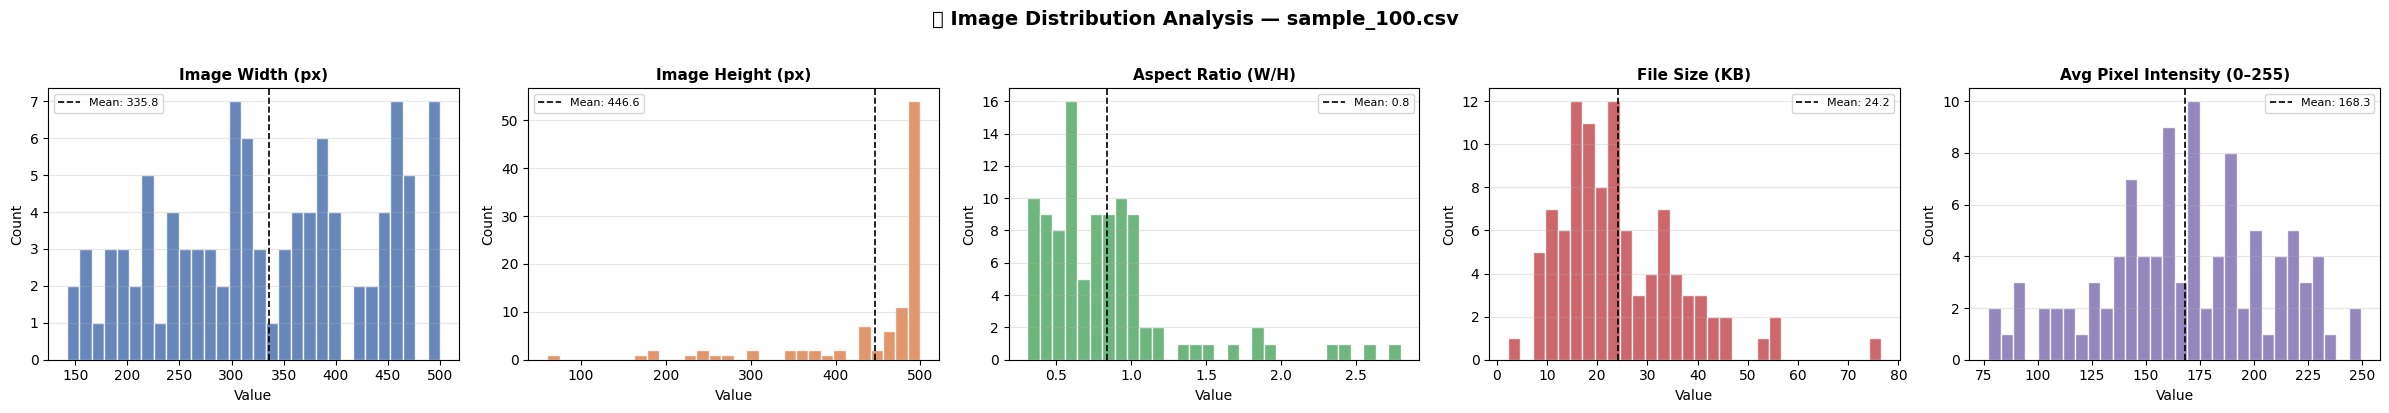

   ✅ Distribution plots rendered for 'sample_100.csv'.

🖼️  Step 6 — Displaying random image samples...


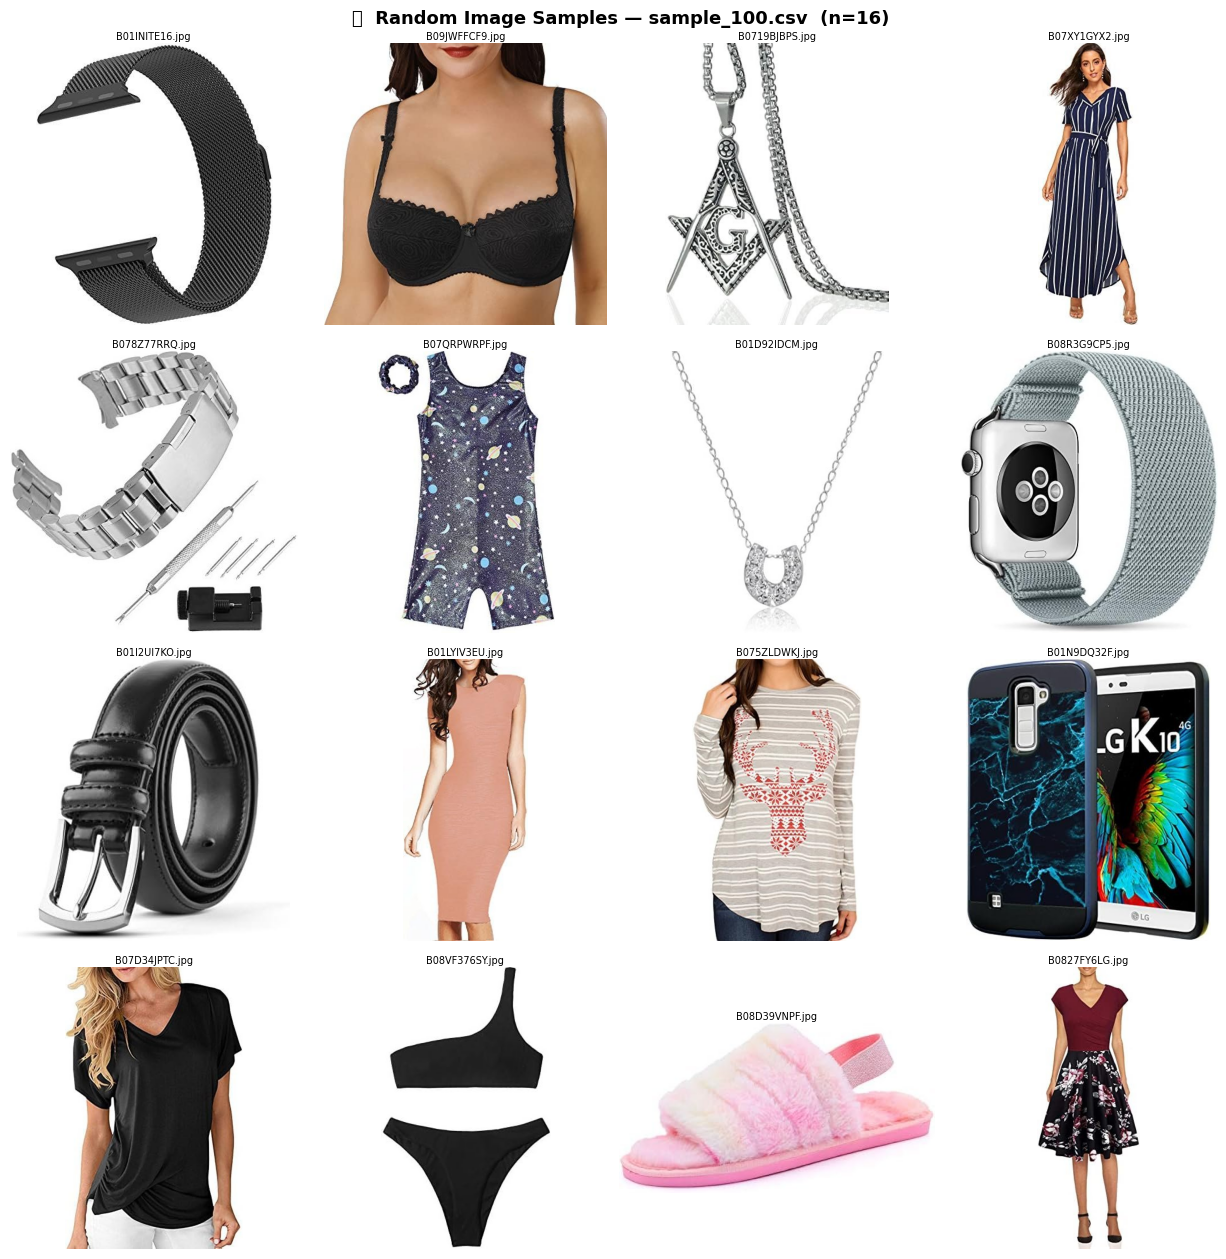

   ✅ Sample grid rendered (16 images).

  🔍  IMAGE ANALYSIS INSIGHT SUMMARY — sample_100.csv

  📌 Total images attempted : 100
  📌 Successfully analyzed  : 100
  📌 Failed / Corrupted     : 0
  📌 Success rate           : 100.0%

  Q1 — Dimension Consistency:
       Width  → mean=336px  std=102px  CV=30.2%
       Height → mean=447px  std=90px  CV=20.1%
       Result → ⚠️  HIGH VARIATION (CV ≥ 15%)

  Q2 — Preprocessing Correctness (resize cap: 512px):
       Images exceeding 512px in any dimension : 0
       Result → ✅ RESIZE APPLIED CORRECTLY

  Q3 — Visual Richness (dataset-relative, percentile-based):
       Rich threshold  (p75): 94.94  →  25 images above (25.0%)
       Plain threshold (p25): 63.71  →  25 images below (25.0%)
       Dataset std_intensity → mean=79.54  median=85.24  IQR=31.24
       Result → ✅ VISUALLY DIVERSE — strong texture variation across dataset

  Q4 — File Size Variation:
       Mean=24.2KB  Min=2.2KB  Max=76.5KB  CV=50.7%
       Result → ✅ SIZE VARIATION MODE

In [11]:
run_pipeline(
    csv_files          = CSV_FILES,
    image_base_dir     = IMAGE_BASE_DIR,
    max_sample_display = MAX_SAMPLE_DISPLAY,
)